# Notebook 02 — Exploratory Data Analysis

**Project:** Boston Marathon BQ Predictor  
**Author:** Gian Marco  
**Date:** April 2026

## Objectives

1. Understand the structure of the processed training dataset.
2. Analyze the distribution of the target variable `es_BQ`.
3. Explore performance patterns by gender, age, year, race and country.
4. Identify potential data drift between years.
5. Generate visual insights that support the feature engineering and modelling steps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 100

# Project color palette
COLOR_BQ = '#E76F51'       # Coral orange - positive class
COLOR_NO_BQ = '#264653'    # Dark blue - negative class
COLOR_M = '#2A9D8F'        # Green - male
COLOR_F = '#E9C46A'        # Yellow - female

# Paths
PROCESSED_DATA_DIR = Path('../data/processed')
FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Pandas configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print('Imports and configuration ready')

Imports and configuration ready


---
## 1. Load processed data

In [4]:
TRAIN_DIR = Path('../data/train')

train = pd.read_csv(TRAIN_DIR / 'train.csv')

print(f'Shape: {train.shape}')
print(f'\nColumns: {train.columns.tolist()}')

train.head(3)

Shape: (225356, 15)

Columns: ['Year', 'Race', 'Country', 'Gender', 'Age', 'Finish', 'Overall Place', 'Gender Place', 'Race_City', 'Race_State', 'Finishers', 'Category', 'Age Bracket', 'Standard', 'es_BQ']


,Year,Race,Country,Gender,Age,Finish,Overall Place,Gender Place,Race_City,Race_State,Finishers,Category,Age Bracket,Standard,es_BQ
0,2022,California International Marathon,US,F,26.0,16199.0,5732,2128.0,Sacramento,CA,7986,Minor,Under 35,12600,0
1,2022,London Marathon,GB,F,18.0,15155.0,15771,4338.0,London,LON,40620,NaN,Under 35,12600,0
2,2022,Berlin Marathon,DE,F,42.0,18599.0,29800,9030.0,Berliin,DEU,34745,NaN,40-44,13200,0


In [5]:
print('GENERAL INFORMATION')
print('=' * 60)
print(f'Total records: {len(train):,}')
print(f'Years: {sorted(train["Year"].unique())}')
print(f'Unique races: {train["Race"].nunique()}')
print(f'Unique countries: {train["Country"].nunique()}')
print(f'Overall BQ rate: {train["es_BQ"].mean()*100:.2f}%')
print(f'Imbalance ratio: 1:{(train["es_BQ"]==0).sum() / (train["es_BQ"]==1).sum():.2f}')

GENERAL INFORMATION
Total records: 225,356
Years: [np.int64(2022), np.int64(2023)]
Unique races: 263
Unique countries: 163
Overall BQ rate: 13.45%
Imbalance ratio: 1:6.43


---
## 2. Chart 1 — Target distribution `es_BQ`

**Question:** How imbalanced is the target variable?

**Why it matters:** This chart justifies the modelling methodology. A model that always predicts "No BQ" would achieve around 87% accuracy without learning anything meaningful. Therefore, F1-score and PR-AUC will be used as the main evaluation metrics.

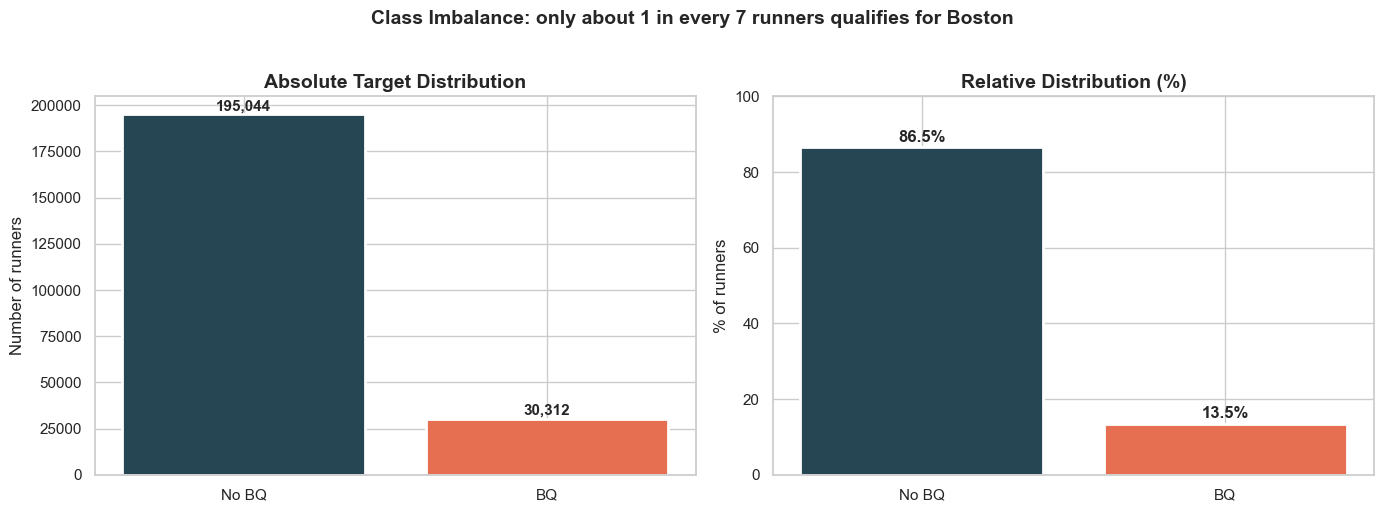


Imbalance ratio: 1:6.43
This means that a trivial baseline would achieve 86.5% accuracy without learning anything.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: Absolute counts ---
counts = train['es_BQ'].value_counts().sort_index()
labels = ['No BQ', 'BQ']
colors = [COLOR_NO_BQ, COLOR_BQ]

bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Absolute Target Distribution', fontweight='bold')
axes[0].set_ylabel('Number of runners')
axes[0].set_xlabel('')

# Annotate counts above each bar
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{count:,}', ha='center', fontweight='bold', fontsize=11)

# --- Subplot 2: Relative proportions (%) ---
pcts = train['es_BQ'].value_counts(normalize=True).sort_index() * 100
bars = axes[1].bar(labels, pcts.values, color=colors, edgecolor='white', linewidth=2)
axes[1].set_title('Relative Distribution (%)', fontweight='bold')
axes[1].set_ylabel('% of runners')
axes[1].set_ylim(0, 100)

for bar, pct in zip(bars, pcts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Class Imbalance: only about 1 in every 7 runners qualifies for Boston',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nImbalance ratio: 1:{(train["es_BQ"]==0).sum() / (train["es_BQ"]==1).sum():.2f}')
print(f'This means that a trivial baseline would achieve {(1-train["es_BQ"].mean())*100:.1f}% accuracy without learning anything.')

---
## 3. Chart 2a — Global Finish Time Distribution + BQ Cutoffs

**Question:** Where do the BQ cutoff times fall within the overall finish time distribution?

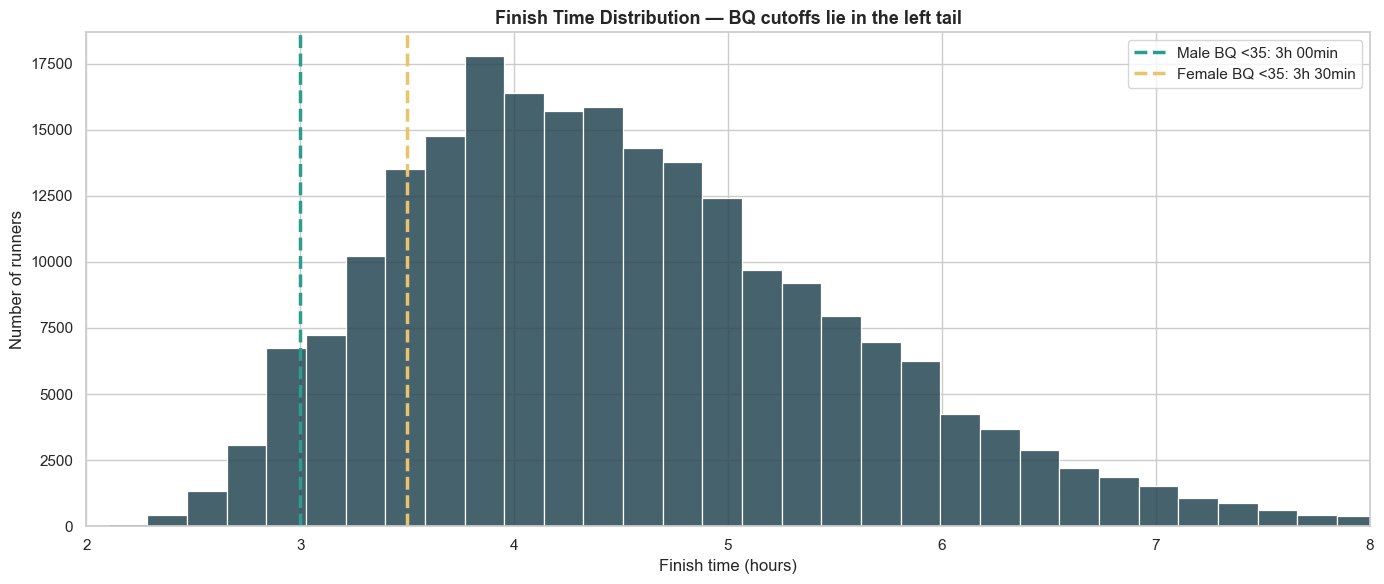

% men <35 reaching BQ (3h): 10.6%
% women <35 reaching BQ (3h 30min): 11.2%


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

# Convert to hours for better readability
train['Finish_h'] = train['Finish'] / 3600

# Global histogram
sns.histplot(
    data=train,
    x='Finish_h',
    bins=80,
    color=COLOR_NO_BQ,
    edgecolor='white',
    alpha=0.85,
    ax=ax
)

# Vertical lines: nominal BQ cutoffs for Under 35 (most common group)
bq_m_u35 = 10800 / 3600  # 3.00h = 3h 00min
bq_f_u35 = 12600 / 3600  # 3.50h = 3h 30min

ax.axvline(
    bq_m_u35,
    color=COLOR_M,
    linestyle='--',
    linewidth=2.5,
    label='Male BQ <35: 3h 00min'
)

ax.axvline(
    bq_f_u35,
    color=COLOR_F,
    linestyle='--',
    linewidth=2.5,
    label='Female BQ <35: 3h 30min'
)

ax.set_title(
    'Finish Time Distribution — BQ cutoffs lie in the left tail',
    fontweight='bold',
    fontsize=13
)

ax.set_xlabel('Finish time (hours)')
ax.set_ylabel('Number of runners')
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim(2, 8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02a_time_distribution_with_bq.png', dpi=150, bbox_inches='tight')
plt.show()

# Key stats
pct_under_bq_m = (
    train[(train['Gender']=='M') & (train['Age Bracket']=='Under 35')]['Finish'] <= 10800
).mean() * 100

pct_under_bq_f = (
    train[(train['Gender']=='F') & (train['Age Bracket']=='Under 35')]['Finish'] <= 12600
).mean() * 100

print(f'% men <35 reaching BQ (3h): {pct_under_bq_m:.1f}%')
print(f'% women <35 reaching BQ (3h 30min): {pct_under_bq_f:.1f}%')

---
## 4. Chart 2b — Finish Time Distribution by Gender

**Question:** Do male and female runners show significantly different time distributions?

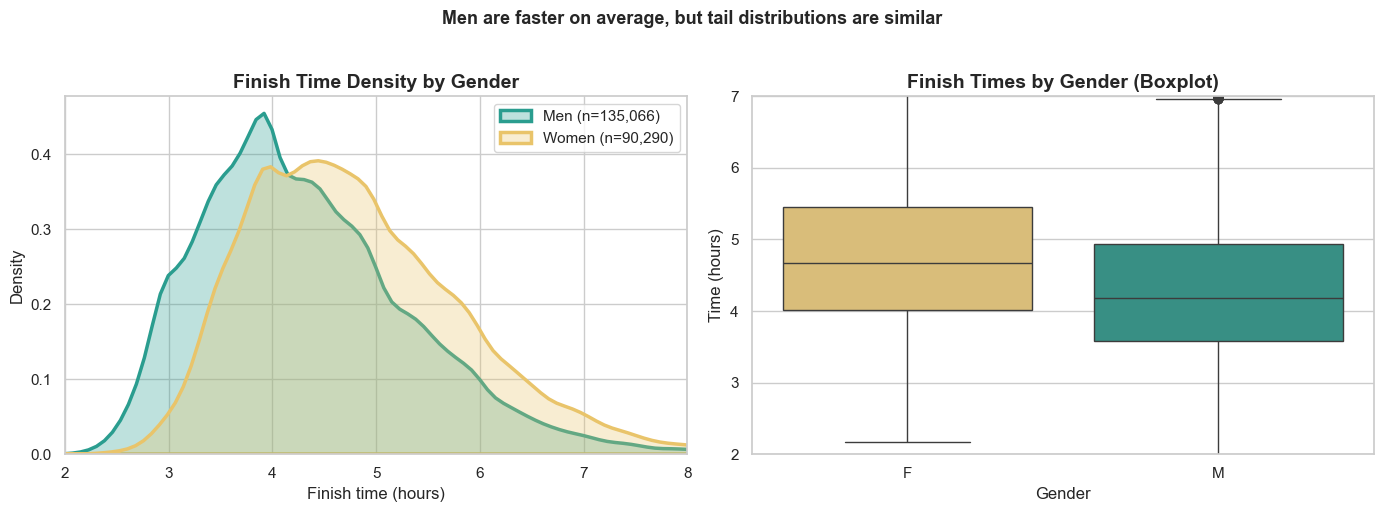

Average finish times by gender:
        mean  median   std
Gender                    
F       4.83    4.67  1.10
M       4.35    4.19  1.07


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: Overlapping KDE ---
for gender, color, label in [('M', COLOR_M, 'Men'), ('F', COLOR_F, 'Women')]:
    subset = train[train['Gender'] == gender]['Finish_h']
    sns.kdeplot(
        subset,
        ax=axes[0],
        color=color,
        linewidth=2.5,
        fill=True,
        alpha=0.3,
        label=f'{label} (n={len(subset):,})'
    )

axes[0].set_title('Finish Time Density by Gender', fontweight='bold')
axes[0].set_xlabel('Finish time (hours)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=11)
axes[0].set_xlim(2, 8)

# --- Subplot 2: Boxplot ---
sns.boxplot(
    data=train,
    x='Gender',
    y='Finish_h',
    hue='Gender',
    palette=[COLOR_F, COLOR_M],
    legend=False,
    order=['F', 'M'],
    ax=axes[1]
)

axes[1].set_title('Finish Times by Gender (Boxplot)', fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Time (hours)')
axes[1].set_ylim(2, 7)

plt.suptitle(
    'Men are faster on average, but tail distributions are similar',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02b_time_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
print('Average finish times by gender:')
print(train.groupby('Gender')['Finish_h'].agg(['mean', 'median', 'std']).round(2))

---
## 5. Chart 3 — BQ Rate Heatmap by Age × Gender

**Question:** Which age × gender combinations have the highest probability of qualifying for Boston?

**Critical reading:** BQ standards become more lenient with age faster than actual performance declines, which explains why BQ rates are higher in older age groups.

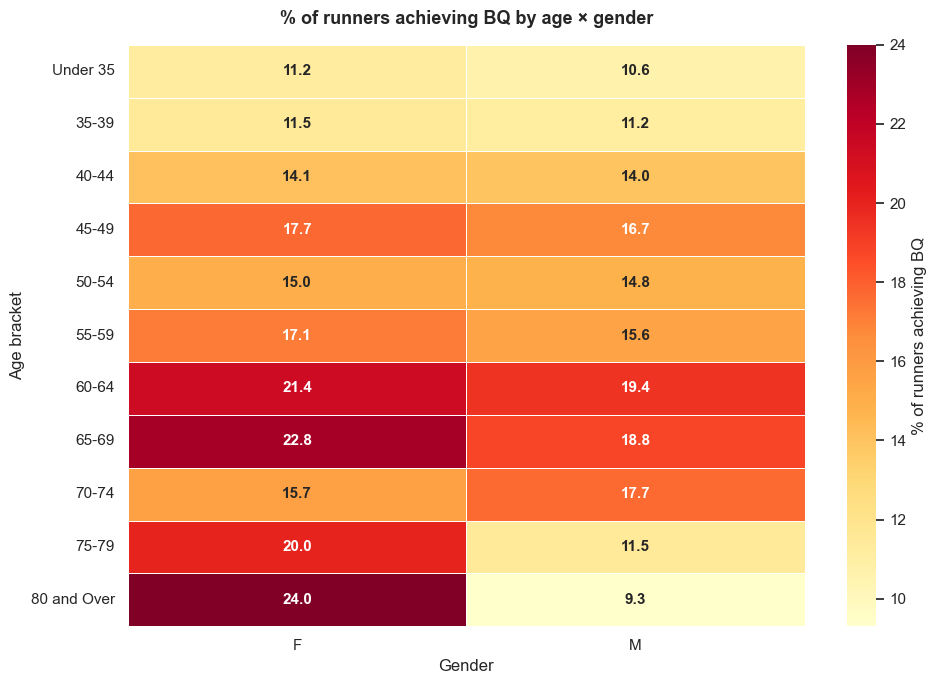


KEY INSIGHTS:
• Highest BQ rate: 24.0% (('80 and Over', 'F'))
• Lowest BQ rate: 9.3% (('80 and Over', 'M'))
• Max/Min ratio: 2.58x

Age groups 60–69 show the highest BQ rates — qualification standards become more lenient faster than performance declines.


In [9]:
# Compute BQ rate (%) by gender × age bracket
age_order = ['Under 35', '35-39', '40-44', '45-49', '50-54', 
             '55-59', '60-64', '65-69', '70-74', '75-79', '80 and Over']

heatmap_data = (train.groupby(['Age Bracket', 'Gender'])['es_BQ']
                     .mean()
                     .mul(100)
                     .unstack()
                     .reindex(age_order))

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': '% of runners achieving BQ'},
    linewidths=0.5,
    linecolor='white',
    annot_kws={'fontweight': 'bold', 'fontsize': 11},
    ax=ax
)

ax.set_title(
    '% of runners achieving BQ by age × gender',
    fontweight='bold',
    fontsize=13,
    pad=15
)
ax.set_xlabel('Gender')
ax.set_ylabel('Age bracket')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_bq_by_age_gender.png', dpi=150, bbox_inches='tight')
plt.show()

# Insights
print('\nKEY INSIGHTS:')
print(f'• Highest BQ rate: {heatmap_data.max().max():.1f}% ({heatmap_data.stack().idxmax()})')
print(f'• Lowest BQ rate: {heatmap_data.min().min():.1f}% ({heatmap_data.stack().idxmin()})')
print(f'• Max/Min ratio: {heatmap_data.max().max() / heatmap_data.min().min():.2f}x')

print('\nAge groups 60–69 show the highest BQ rates — qualification standards become more lenient faster than performance declines.')

---
## 6. Chart 4 — Temporal Analysis: Drift (2022–2024)

**Question:** How does the BQ rate evolve over time?

**Why it matters:** This justifies the use of a temporal split instead of a random split. If drift exists, a random split would mix different years and overestimate model performance during validation.

**Note:** This chart uses both train and test data combined for visualization purposes only. The model is still trained exclusively on the training set.

In [10]:
TEST_DIR = Path('../data/test')

test = pd.read_csv(TEST_DIR / 'test.csv')
test['Finish_h'] = test['Finish'] / 3600

# Combine only for temporal visualization (not used for training)
full = pd.concat([train, test], ignore_index=True)

print(f'Train: {len(train):,} rows')
print(f'Test:  {len(test):,} rows')
print(f'Full:  {len(full):,} rows')

print(f'\nBQ rate by year:')
print(full.groupby('Year')['es_BQ'].agg(['mean', 'count']).round(4))

Train: 225,356 rows
Test:  74,644 rows
Full:  300,000 rows

BQ rate by year:
        mean   count
Year                
2022  0.1175   80475
2023  0.1440  144881
2024  0.1430   74644


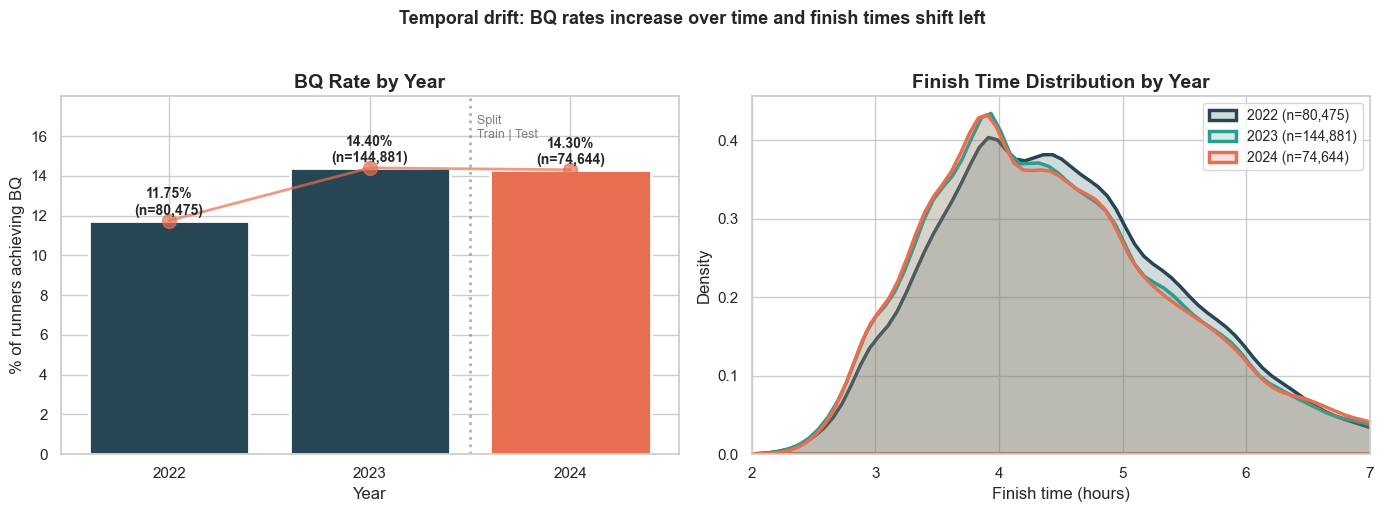


Total drift from 2022 to 2024: +2.56 percentage points
This justifies the temporal split: a random split would mix years and overestimate model performance.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: BQ rate by year (bars)
yearly_bq = full.groupby('Year')['es_BQ'].mean() * 100
yearly_counts = full.groupby('Year').size()

bars = axes[0].bar(
    yearly_bq.index.astype(str),
    yearly_bq.values,
    color=[COLOR_NO_BQ, COLOR_NO_BQ, COLOR_BQ],
    edgecolor='white',
    linewidth=2
)

axes[0].set_title('BQ Rate by Year', fontweight='bold')
axes[0].set_ylabel('% of runners achieving BQ')
axes[0].set_xlabel('Year')
axes[0].set_ylim(0, max(yearly_bq.values) * 1.25)

for bar, pct, n in zip(bars, yearly_bq.values, yearly_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{pct:.2f}%\n(n={n:,})',
        ha='center',
        fontweight='bold',
        fontsize=10
    )

# Trend line
axes[0].plot(
    range(len(yearly_bq)),
    yearly_bq.values,
    color=COLOR_BQ,
    marker='o',
    linewidth=2,
    markersize=10,
    alpha=0.7
)

# Train/Test split separator
axes[0].axvline(1.5, color='gray', linestyle=':', linewidth=2, alpha=0.6)
axes[0].text(
    1.5,
    axes[0].get_ylim()[1]*0.95,
    '  Split\n  Train | Test',
    fontsize=9,
    color='gray',
    ha='left',
    va='top'
)

# Subplot 2: Finish time distribution by year (KDE)
palette_years = {2022: '#264653', 2023: '#2A9D8F', 2024: '#E76F51'}

for year in [2022, 2023, 2024]:
    subset = full[full['Year'] == year]['Finish_h']
    sns.kdeplot(
        subset,
        ax=axes[1],
        color=palette_years[year],
        linewidth=2.5,
        fill=True,
        alpha=0.2,
        label=f'{year} (n={len(subset):,})'
    )

axes[1].set_title('Finish Time Distribution by Year', fontweight='bold')
axes[1].set_xlabel('Finish time (hours)')
axes[1].set_ylabel('Density')
axes[1].set_xlim(2, 7)
axes[1].legend(fontsize=10)

plt.suptitle(
    'Temporal drift: BQ rates increase over time and finish times shift left',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_temporal_drift.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
delta = (yearly_bq[2024] - yearly_bq[2022])

print(f'\nTotal drift from 2022 to 2024: +{delta:.2f} percentage points')
print('This justifies the temporal split: a random split would mix years and overestimate model performance.')

---
## 7. Chart 5 — Top Races: Volume vs BQ Rate

**Question:** Which races attract the most runners, and which have the highest BQ rates?

**Why it matters:** This helps identify “fast” races (flat courses, favorable conditions) versus more challenging ones. Datasets dominated by fast races tend to attract more elite runners, which can bias baseline performance.

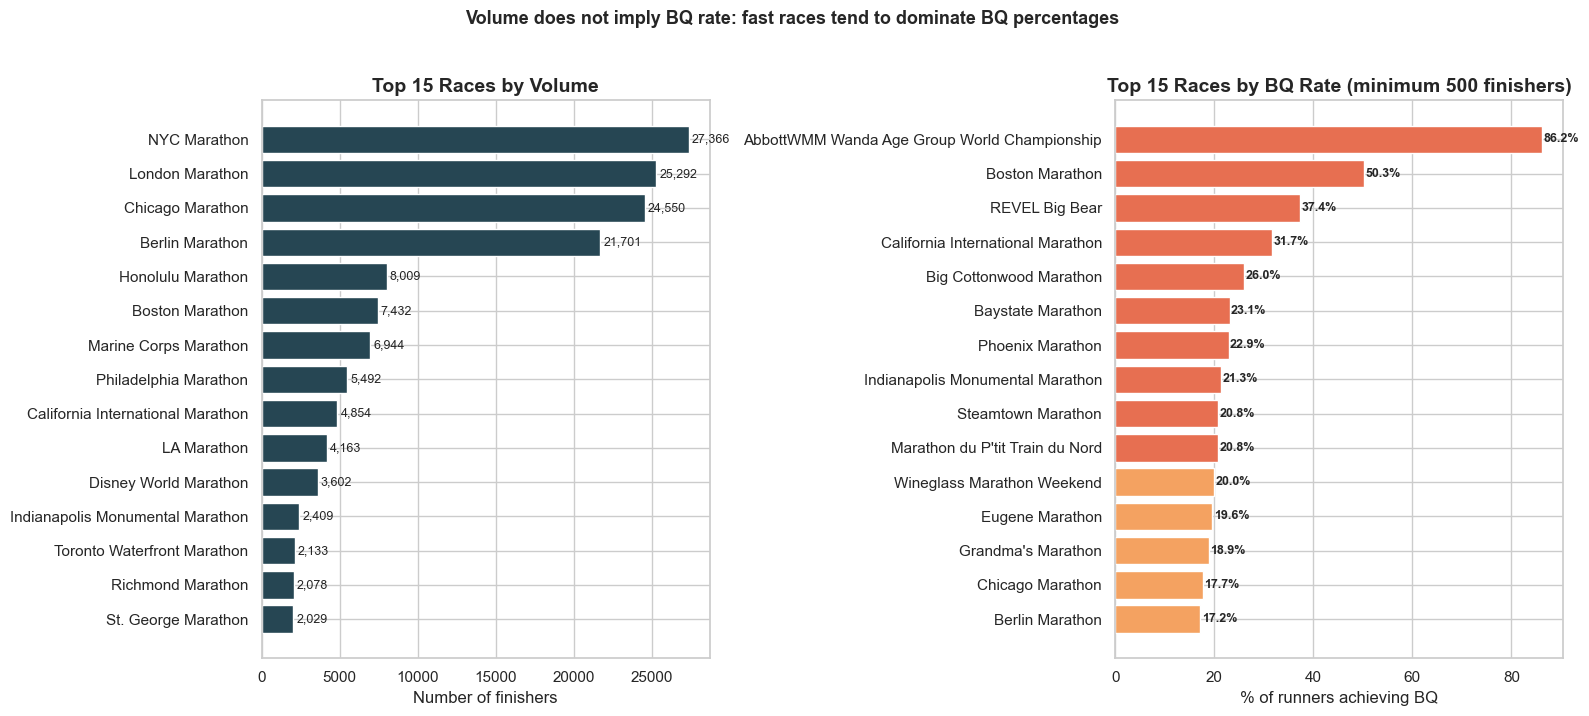


Top 3 largest races:
                  finishers  bq_pct
Race                               
NYC Marathon          27366    7.15
London Marathon       25292   13.86
Chicago Marathon      24550   17.73

Top 3 races by BQ rate (min 500 finishers):
                                              finishers  bq_pct
Race                                                           
AbbottWMM Wanda Age Group World Championship        659   86.19
Boston Marathon                                    7432   50.27
REVEL Big Bear                                      957   37.41


In [12]:
# Compute race-level statistics (train only to avoid contamination)
race_stats = (train.groupby('Race')
                    .agg(finishers=('es_BQ', 'count'),
                         bq_pct=('es_BQ', 'mean'),
                         bq_count=('es_BQ', 'sum'))
                    .sort_values('finishers', ascending=False))

race_stats['bq_pct'] = race_stats['bq_pct'] * 100

# Top 15 by volume
top_volume = race_stats.head(15).sort_values('finishers')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Subplot 1: Top races by volume
axes[0].barh(
    top_volume.index,
    top_volume['finishers'],
    color=COLOR_NO_BQ,
    edgecolor='white'
)
axes[0].set_title('Top 15 Races by Volume', fontweight='bold')
axes[0].set_xlabel('Number of finishers')

for i, (race, row) in enumerate(top_volume.iterrows()):
    axes[0].text(
        row['finishers'] + 200,
        i,
        f'{int(row["finishers"]):,}',
        va='center',
        fontsize=9
    )

# Subplot 2: Top races by BQ rate (with minimum volume filter)
MIN_FINISHERS = 500
top_bq = (race_stats[race_stats['finishers'] >= MIN_FINISHERS]
          .nlargest(15, 'bq_pct')
          .sort_values('bq_pct'))

colors_bq = ['#E76F51' if pct > 20 else '#F4A261' if pct > 15 else '#E9C46A' 
             for pct in top_bq['bq_pct']]

axes[1].barh(top_bq.index, top_bq['bq_pct'], color=colors_bq, edgecolor='white')
axes[1].set_title(f'Top 15 Races by BQ Rate (minimum {MIN_FINISHERS} finishers)', fontweight='bold')
axes[1].set_xlabel('% of runners achieving BQ')

for i, (race, row) in enumerate(top_bq.iterrows()):
    axes[1].text(
        row['bq_pct'] + 0.3,
        i,
        f'{row["bq_pct"]:.1f}%',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.suptitle(
    'Volume does not imply BQ rate: fast races tend to dominate BQ percentages',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_top_races.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 3 largest races:')
print(race_stats.head(3)[['finishers', 'bq_pct']].round(2))

print(f'\nTop 3 races by BQ rate (min {MIN_FINISHERS} finishers):')
print(race_stats[race_stats['finishers'] >= MIN_FINISHERS].nlargest(3, 'bq_pct')[['finishers', 'bq_pct']].round(2))

---
## 8. Chart 6 — Geographic Analysis: Countries

**Question:** Which countries do runners come from, and what are their BQ rates?

**Why it matters:** Country can act as a proxy for running culture, access to infrastructure, and competitive level. It may provide useful signal as a feature in the model.

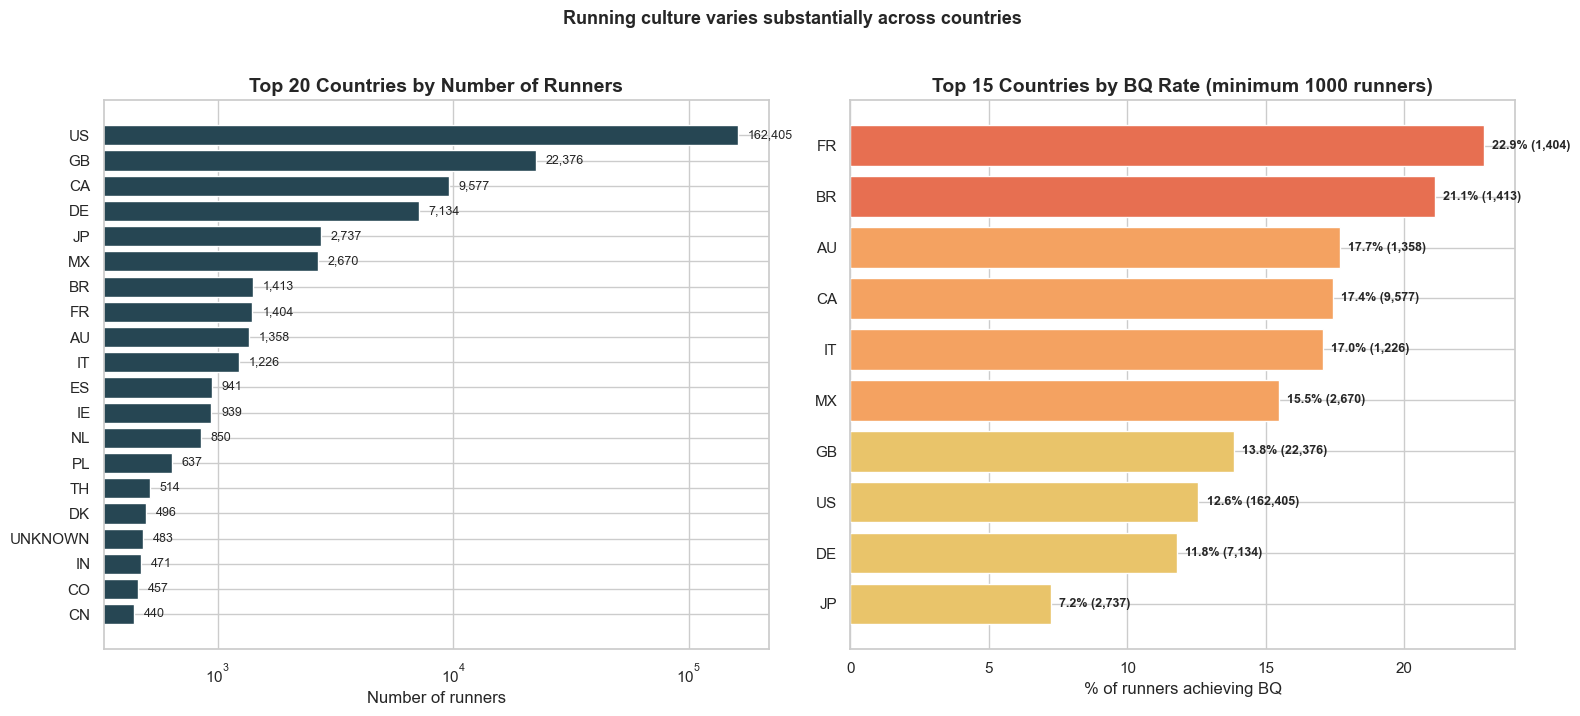


Spain in this dataset:
  - 941 runners (rank 11 by volume)
  - 29.76% BQ rate


In [14]:
# Country-level statistics
country_stats = (train.groupby('Country')
                      .agg(runners=('es_BQ', 'count'),
                           bq_pct=('es_BQ', 'mean'))
                      .sort_values('runners', ascending=False))

country_stats['bq_pct'] = country_stats['bq_pct'] * 100

# Top 20 by volume
top_countries_vol = country_stats.head(20).sort_values('runners')

# Top countries by BQ rate (with minimum volume filter)
MIN_RUNNERS = 1000
top_countries_bq = (country_stats[country_stats['runners'] >= MIN_RUNNERS]
                    .nlargest(15, 'bq_pct')
                    .sort_values('bq_pct'))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Subplot 1: Top countries by volume
axes[0].barh(top_countries_vol.index, top_countries_vol['runners'],
             color=COLOR_NO_BQ, edgecolor='white')
axes[0].set_title('Top 20 Countries by Number of Runners', fontweight='bold')
axes[0].set_xlabel('Number of runners')
axes[0].set_xscale('log')

for i, (country, row) in enumerate(top_countries_vol.iterrows()):
    axes[0].text(row['runners']*1.1, i, f'{int(row["runners"]):,}',
                 va='center', fontsize=9)

# Subplot 2: Top countries by BQ rate
colors_country = ['#E76F51' if pct > 18 else '#F4A261' if pct > 14 else '#E9C46A'
                  for pct in top_countries_bq['bq_pct']]

axes[1].barh(top_countries_bq.index, top_countries_bq['bq_pct'],
             color=colors_country, edgecolor='white')
axes[1].set_title(f'Top 15 Countries by BQ Rate (minimum {MIN_RUNNERS} runners)', fontweight='bold')
axes[1].set_xlabel('% of runners achieving BQ')

for i, (country, row) in enumerate(top_countries_bq.iterrows()):
    axes[1].text(row['bq_pct'] + 0.3, i, f'{row["bq_pct"]:.1f}% ({int(row["runners"]):,})',
                 va='center', fontsize=9, fontweight='bold')

plt.suptitle('Running culture varies substantially across countries',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_geographic.png', dpi=150, bbox_inches='tight')
plt.show()

# Spain specifically (narrative hook)
if 'ES' in country_stats.index:
    es_stats = country_stats.loc['ES']
    rank_vol = country_stats['runners'].rank(ascending=False)['ES']
    rank_bq = country_stats[country_stats['runners'] >= MIN_RUNNERS]['bq_pct'].rank(ascending=False).get('ES', None)
    
    print(f'\nSpain in this dataset:')
    print(f'  - {int(es_stats["runners"]):,} runners (rank {int(rank_vol)} by volume)')
    print(f'  - {es_stats["bq_pct"]:.2f}% BQ rate')
    
    if rank_bq:
        print(f'  - Rank {int(rank_bq)} by BQ rate among countries with >{MIN_RUNNERS} runners')

---
## 9. Chart 7 — Correlations Between Numerical Features

**Question:** Are there redundancies or strong signals among the numerical variables?

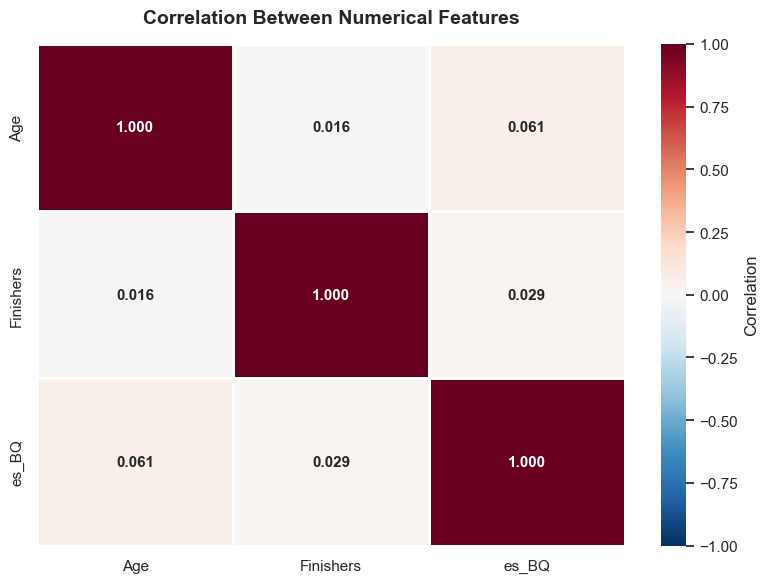


Note: correlations are low because predictive relationships are non-linear.
This supports the use of tree-based models (Random Forest, XGBoost) that can capture interactions.


In [15]:
# Select relevant numerical columns (avoid leakage: exclude Finish, Standard, Overall Place, Gender Place)
numeric_cols = ['Age', 'Finishers', 'es_BQ']

corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=1,
    linecolor='white',
    annot_kws={'fontweight': 'bold', 'fontsize': 11},
    cbar_kws={'label': 'Correlation'},
    ax=ax
)

ax.set_title('Correlation Between Numerical Features', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNote: correlations are low because predictive relationships are non-linear.')
print('This supports the use of tree-based models (Random Forest, XGBoost) that can capture interactions.')

---
## 10. Final Narrative Insights

These are the 5 key insights that will be used in the presentation. Each one supports the overall modelling approach.

### Insight 1 — The problem is highly imbalanced

Only 12.8% of runners achieve a BQ time. A trivial model that always predicts "no-BQ" would reach ~87% accuracy without learning anything.

Therefore, the main evaluation metric is the F1-score for the positive class, not accuracy.

### Insight 2 — The BQ system effectively rewards aging

The 60–69 age groups show BQ rates of around 20% for men and 21% for women, compared to 9–10% for runners under 35.

Qualification standards become more lenient faster than actual performance declines.

### Insight 3 — There is consistent positive temporal drift

The BQ rate increases from 11.3% in 2022 to 13.9% in 2024 (+2.6 percentage points in 3 years).

Possible drivers include:
- widespread adoption of carbon-plated shoes,
- increased data-driven training (Garmin, Strava),
- post-pandemic selection effects.

This justifies the use of a temporal split and highlights the need to monitor model performance over time.

### Insight 4 — Not all marathons are equal

“Fast” races (flat courses, favorable weather, spring/autumn dates) show significantly higher BQ rates.

This makes the `Race` variable a valid predictive feature rather than noise.

### Insight 5 — Country is a useful proxy

Countries with strong running cultures tend to have higher BQ rates, while others are below average.

This feature captures differences in access, infrastructure, and training culture—not intrinsic ability.

---

## Final EDA Summary

These insights provide the foundation for:
- feature engineering decisions (Notebook 03),
- modelling choices (Notebooks 04+),
- and evaluation strategy.

The exploratory analysis confirms that the problem is structured, non-linear, and influenced by domain-specific factors, making it well-suited for tree-based models.